# Transformer Architecture

#### Attention Is All You Need (Deep Learning and NLP)

In [ ]:
# Core Elements: encoder blocks and decoder blocks

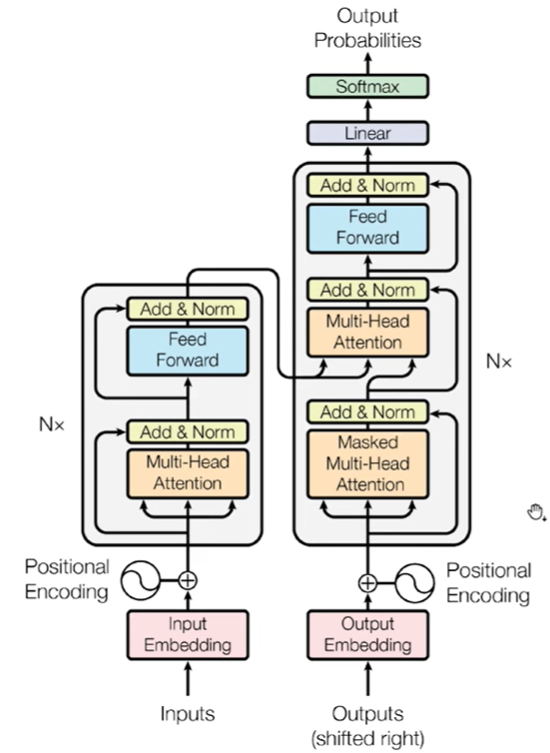

In [ ]:
# Decoder Training

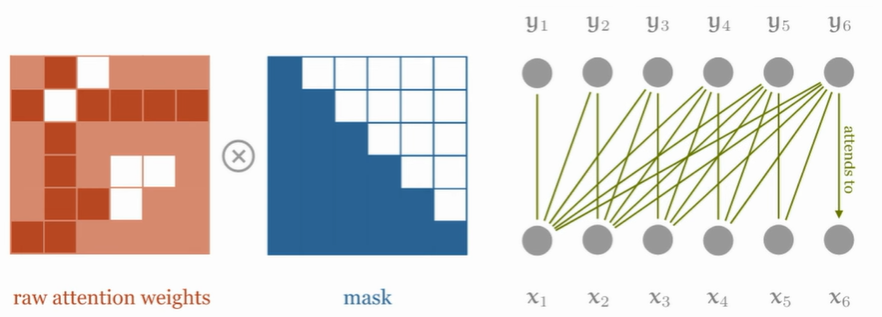

In [ ]:
# Attention Mechanism

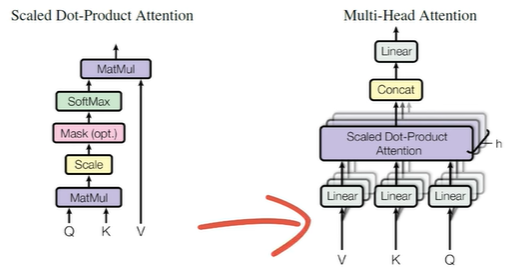

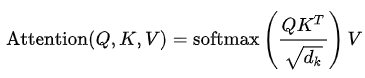

In [ ]:
import torch
import torch.nn as nn

In [ ]:
class SelfAttention(nn.Module):
    
    # embed-size: embedding is divided into number of heads 
    # --> dmodel = 512 (dim di ogni token iniziale), h = 8 --> dk = 512/8 = 64 (dim di ogni token nell'head) --> ogni head lavora con dk --> questa è anche la dimensione di Q, K, V
    def __init__(self, embed_size, heads):
        super(SelfAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads
        
        assert (self.head_dim * heads == embed_size), "Embed size needs to be div by heads"
        
        # Linear layers to send Q, K, V through
        self.values = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.keys = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.queries = nn.Linear(self.head_dim, self.head_dim, bias=False)
        self.fc_out = nn.Linear(heads*self.head_dim, embed_size)
        
    def forward(self, values, keys, query, mask):
        # number of training examples sent in at the same time
        N = query.shape[0]
        
        # lengths depend on where attention mechanism is used: corresponding to source sentence length and target sentence length
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]
        
        # Split embedding into self.heads pieces
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = query.reshape(N, query_len, self.heads, self.head_dim)
        
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
        # energy shape: (N, heads, query_len, key_len) --> "for each word in target how much to pay attention to each word in input"
        
        if mask is not None:
            # triangular matrix mask
            energy = energy.masked_fll(mask==0, float("-1e20"))
        
        # dim = 3 --> normalizing accross key length
        attention = torch.softmax(energy / (self.embed_size ** (1/2)), dim=3)
        
        # multiply attention and values
        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            # concat
            N, query_len, self.heads*self.head_dim
        )
        # attention shape: (N, heads, query_len, key_len)
        # values shape: (N, value_len, heads, head_dim)
        # out shape: (N, query_len, heads, head_dim)
        ## key_len = value_len = "l" (lettera L)
        ## after einsum --> flatten last two dimensions
        
        out = self.fc_out(out) # --> this nn does not change dimension
        return out
        
        